In [9]:
from dotenv import load_dotenv
load_dotenv()

import os

import numpy as np
from pixell import enmap, enplot, reproject
import glob
import matplotlib.pyplot as plt
import emcee, corner
from astropy.io import fits
import sys
from astropy import units as u, constants as const
sys.path.insert(0, '../src')
#sys.path.insert(0, "/home/gill/apps/szpack/python")
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
import yaml
import itertools
from pixell import enmap

import bandpass as bp
import covariance as cov
import model
import utils as ut

import SZpack as SZ

from astropy.coordinates import SkyCoord
import astropy.units as u

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
def converge_plot(sampler, labels):
    plt.figure(figsize=(12, 8))
    for idx in range(len(labels)):
        chain = sampler.get_chain()[:, :, idx].T

        N = np.exp(np.linspace(np.log(10**2), np.log(chain.shape[1]), 10)).astype(int)
        gw2010 = np.empty(len(N))
        new = np.empty(len(N))
        for i, n in enumerate(N):
            gw2010[i] = ut.autocorr_gw2010(chain[:, :n])
            new[i] = ut.autocorr_new(chain[:, :n])

        plt.loglog(N, new, "o-", label=labels[idx])
        plt.xlabel("number of samples, $N$")
        plt.ylabel(r"$\tau$ estimates")
            
    plt.plot(N, N / 50.0, "--k", label=r"$\tau = N/50$")
    plt.legend(fontsize=8)
    plt.grid()
    plt.show()
    
def plotter_sim(filename, target, p_range, plot_contours=False, fit_dust=True,
                plot_converge=False, burnin=1, 
                plot_samples=True, truths=None,
                thin=1, plot_maps=False, cf_path="cf_auto_all.yaml"):
    
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    filename_case1 = "/home/gill/research/ACT/bridge/results/ajay/final_runs/case54/chain.h5"
    filename_case2 = "/home/gill/research/ACT/bridge/results/ajay/final_runs/case55/chain.h5"
    filename_case3 = "/home/gill/research/ACT/bridge/results/ajay/final_runs/case56/chain.h5"

    sampler_case1 = emcee.backends.HDFBackend(filename_case1)
    sampler_case2 = emcee.backends.HDFBackend(filename_case2)
    sampler_case3 = emcee.backends.HDFBackend(filename_case3)

    cf = ut.get_config_file(f'{cf_path}')

    labels_a401_case1 = [r'RA$_{\rm A401}$ [$^{\circ}$]', 
              r'DEC$_{\rm A401}$ [$^{\circ}$]', 
              r'$\beta_{\rm A401}$', 
              r'$r_{\rm c, A401}$ [$^{\prime}$]', 
              r'$e_{\rm A401}$', 
              r'$\theta_{\rm A401}$ [$^{\circ}$]', 
              r'$\tau_{\rm A401}$', 
              r'$T_{\rm e, A401}$ [keV]', 
              r'$A_{\rm D, A401}$ [Jy/sr]',
              r"$v_{\rm r, A401}$ [km/s]"]

    labels_a401_case2_3 = [r'RA$_{\rm A401}$ [$^{\circ}$]', 
              r'DEC$_{\rm A401}$ [$^{\circ}$]', 
              r'$\beta_{\rm A401}$', 
              r'$r_{\rm c, A401}$ [$^{\prime}$]', 
              r'$e_{\rm A401}$', 
              r'$\theta_{\rm A401}$ [$^{\circ}$]', 
              r'$\tau_{\rm A401}$', 
              r'$T_{\rm e, A401}$ [keV]', 
              r'$A_{\rm D, A401}$ [Jy/sr]']

    labels_a399_case1 = [r'$RA_{\rm A399}$ [$^{\circ}$]', 
              r'$DEC_{\rm A399}$ [$^{\circ}$]', 
              r'$\beta_{\rm A399}$', 
              r'$r_{\rm c, A399}$ [$^{\prime}$]', 
              r'$e_{\rm A399}$', 
              r'$\theta_{\rm A399}$ [$^{\circ}$]', 
              r'$\tau_{\rm A399}$', 
              r'$T_{\rm e, A399}$ [keV]', 
              r'$A_{\rm D, A399}$ [Jy/sr]',
              r"$v_{\rm r, A399}$ [km/s]"]

    labels_fil_case1 =  [r"RA$_{\rm fil}$ [$^{\circ}$]",
              r"DEC$_{\rm fil}$ [$^{\circ}$]",
              r"$L_{\rm fil}$ [$^{\prime}$]",
              r"$W_{\rm fil}$ [$^{\prime}$]",
              r'$\tau_{\rm fil}$',
              r'$T_{\rm e, fil}$ [keV]',
              r'$A_{\rm D, fil}$ [Jy/sr]',
              r"$v_{\rm fil}$ [km/s]"]


    labels_a399_case2 = [r'$RA_{\rm A399}$ [$^{\circ}$]', 
              r'$DEC_{\rm A399}$ [$^{\circ}$]', 
              r'$\beta_{\rm A399}$', 
              r'$r_{\rm c, A399}$ [$^{\prime}$]', 
              r'$e_{\rm A399}$', 
              r'$\theta_{\rm A399}$ [$^{\circ}$]', 
              r'$\tau_{\rm A399}$', 
              r'$T_{\rm e, A399}$ [keV]', 
              r'$A_{\rm D, A399}$ [Jy/sr]']

    labels_fil_case2 =  [r"RA$_{\rm fil}$ [$^{\circ}$]",
              r"DEC$_{\rm fil}$ [$^{\circ}$]",
              r"$L_{\rm fil}$ [$^{\prime}$]",
              r"$W_{\rm fil}$ [$^{\prime}$]",
              r'$\tau_{\rm fil}$',
              r'$T_{\rm e, fil}$ [keV]',
              r'$A_{\rm D, fil}$ [Jy/sr]',
              r"$v_{\rm system}$ [km/s]"]
    
    region = ut.get_region(cf['region_center_ra'], 
                           cf['region_center_dec'], 
                           cf['region_width'])
    
    dire_data = "/home/gill/research/ACT/bridge/data_paper/data/data/act_no_reproj"
    data_ref = enmap.read_map(f"{dire_data}/act_cut_dr6v2_pa5_f098_4way_coadd_map_srcfree.fits", 
                              box=region)
    
    data_wcs = data_ref.wcs
    
    # Process all three cases
    cases = [(sampler_case1, "Case 1"), (sampler_case2, "Case 2"), (sampler_case3, "Case 3")]
    all_samples = []

    columns_a401_case1 = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  # All 10 parameters for case 1
    columns_a401_case2_3 = [0, 1, 2, 3, 4, 5, 6, 7, 8]   # First 9 parameters for cases 2 and 3

    truths = []

    Te_a401_mean = 8.47
    Te_a401_std = 0.25

    Te_a399_mean = 7.23
    Te_a399_std = 0.19

    Te_fil_mean = 6.52
    Te_fil_std = 0.35
    
    Te_a401_idx = 7
    Te_a399_idx = 16
    Te_fil_idx = 23

    for sampler, case_name in cases:
        print(f"\nProcessing {case_name}")
        
        idx_ra_401_pix = 0
        idx_dec_401_pix = 1
        
        idx_ra_399_pix = 10
        idx_dec_399_pix = 11

        idx_ra_fil_pix = 19
        idx_dec_fil_pix = 20

        idx_e_a401_pix = 4
        idx_e_a399_pix = 14
        
        samples = sampler.get_chain(discard=burnin, flat=True, thin=thin)
        
        print(f"Number of iterations: {samples.shape[0] / sampler.shape[0]:.0f}")

        a401_ra_pix = samples[:, idx_ra_401_pix]
        a401_dec_pix = samples[:, idx_dec_401_pix]
        
        a399_ra_pix = samples[:, idx_ra_399_pix]
        a399_dec_pix = samples[:, idx_dec_399_pix]
        
        fil_ra_pix = samples[:, idx_ra_fil_pix]
        fil_dec_pix = samples[:, idx_dec_fil_pix]
        
        ra_a401 = data_ref.wcs.celestial.wcs_pix2world(a401_ra_pix, a401_dec_pix, 0)[0]
        dec_a401 = data_ref.wcs.celestial.wcs_pix2world(a401_ra_pix, a401_dec_pix, 0)[1]
          
        ra_a399 = data_ref.wcs.celestial.wcs_pix2world(a399_ra_pix, a399_dec_pix, 0)[0]
        dec_a399 = data_ref.wcs.celestial.wcs_pix2world(a399_ra_pix, a399_dec_pix, 0)[1]
            
        ra_fil = data_ref.wcs.celestial.wcs_pix2world(fil_ra_pix, fil_dec_pix, 0)[0]
        dec_fil = data_ref.wcs.celestial.wcs_pix2world(fil_ra_pix, fil_dec_pix, 0)[1]
        
        samples[:, idx_ra_401_pix] = ra_a401
        samples[:, idx_dec_401_pix] = dec_a401

        samples[:, idx_ra_399_pix] = ra_a399
        samples[:, idx_dec_399_pix] = dec_a399
        
        samples[:, idx_ra_fil_pix] = ra_fil
        samples[:, idx_dec_fil_pix] = dec_fil
        
        samples[:, 20] *= 0.5
        samples[:, 21] *= 0.5

        samples[:, idx_e_a401_pix] = 1 / samples[:, idx_e_a401_pix]
        samples[:, idx_e_a399_pix] = 1 / samples[:, idx_e_a399_pix]

        # Select appropriate columns based on case
        if case_name == "Case 1":
            samples_short = samples[:, columns_a401_case1]
            current_labels = labels_a401_case1
        else:
            samples_short = samples[:, columns_a401_case2_3]
            current_labels = labels_a401_case2_3
            
        all_samples.append(samples_short)
        
        # Print statistics for this case
        for idx, label in enumerate(current_labels):
            mcmc_run = np.percentile(samples_short[:, idx], [16, 50, 84])
            q = np.diff(mcmc_run)
            if case_name == "Case 1":
                truths.append(mcmc_run[1])
            print(f"{case_name} - {label}: {mcmc_run[1]:.6f}, +/- {q[0]:.6f} {q[1]:.6f}")

    if plot_contours:
        plt.rcParams['text.usetex'] = True
        plt.rcParams['font.size'] = 35
        plt.rcParams['font.family'] = 'sans-serif'
        
        # Create labels that include velocity for comparison
        #labels_with_velocity = labels_a399_case2_3 + [r"$v_{\rm r, A399}$ [km/s]"]

        # Prepare data: first 9 parameters for all cases, plus velocity for case 1
        samples_case1_9 = all_samples[0][:, :9]  # First 9 parameters from case 1
        samples_case2_9 = all_samples[1]  # Already 9 parameters
        samples_case3_9 = all_samples[2]  # Already 9 parameters
        
        figure = corner.corner(samples_case1_9, 
               labels=labels_a401_case2_3,
               color='C1',
               levels=None,
               show_titles=False, 
               truths=truths[:9] if truths else None,
               truth_color='black',
               plot_datapoints=False,
               title_fmt=".3f",
               range=p_range[:9] if p_range else None,
               weights=np.ones(len(samples_case1_9))/len(samples_case1_9),  
               hist_kwargs={'linewidth': 3, 'alpha': 1})

        corner.corner(samples_case2_9, fig=figure, range=p_range[:9] if p_range else None, 
                    weights=np.ones(len(samples_case2_9))/len(samples_case2_9), color='C2',
                    plot_datapoints=False, levels=None, hist_kwargs={'linewidth': 3, 'alpha': 1})

        corner.corner(samples_case3_9, fig=figure, range=p_range[:9] if p_range else None, 
                    weights=np.ones(len(samples_case3_9))/len(samples_case3_9), color='C0', 
                    plot_datapoints=False, levels=None, hist_kwargs={'linewidth': 3, 'alpha': 1})

        figure.suptitle('Abell 401 posterior distributions', fontsize=80, x=0.9, y=2.9)
        figure.subplots_adjust(right=3, top=3)

        for ax in figure.get_axes():
            ax.tick_params(axis='both', labelsize=40)
            ax.xaxis.label.set_size(60)
            ax.yaxis.label.set_size(60)
        
        # Add Gaussian temperature prior for A401
        Te_a401_idx_plot = 7  # Index for Te_A401 in the corner plot
        axes = figure.get_axes()
        # Find the diagonal plot for Te_A401
        diagonal_idx = Te_a401_idx_plot * len(labels_a401_case2_3) + Te_a401_idx_plot
        if diagonal_idx < len(axes):
            ax_temp = axes[diagonal_idx]
            x_range = ax_temp.get_xlim()
            y_range = ax_temp.get_ylim()
            x_vals = np.linspace(x_range[0], x_range[1], 1000)
            
            # Plot normalized Gaussian prior for A401
            gaussian_a401 = np.exp(-0.5 * ((x_vals - Te_a401_mean) / Te_a401_std)**2)
            # Scale to match the histogram amplitude
            gaussian_a401 = gaussian_a401 / np.max(gaussian_a401) * (y_range[1] - y_range[0]) * 0.8
            ax_temp.plot(x_vals, gaussian_a401, '-', linewidth=5, alpha=1, color="red")
            ax_temp.legend(fontsize=20)
        
        # Add legend
        from matplotlib.lines import Line2D
        legend_elements = [Line2D([0], [0], color='C1', lw=3, label='Case 1 (fit individual velocities)'),
              Line2D([0], [0], color='C2', lw=3, label='Case 2 (fit system velocity)'),
              Line2D([0], [0], color='C0', lw=3, label='Case 3 (fit system velocity and velocity difference)'),
              Line2D([0], [0], color='red', lw=5, label='X-ray temperature prior')]
        figure.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(2.1, 2.75), fontsize=80, frameon=False)
        
        # Change tick font sizes
        for ax in figure.get_axes():
            ax.tick_params(axis='both', labelsize=55)
            ax.xaxis.label.set_size(60)
            ax.yaxis.label.set_size(60)
        
        figure.savefig("../plots/a401_all_cases_corner_sep14.pdf", dpi=400, bbox_inches='tight')
        plt.show()

    if plot_converge:
        print("Convergence plot for Case 1")
        converge_plot(sampler_case1, labels_a401_case1)

In [21]:
def plotter_sim_a399(filename, target, p_range, plot_contours=False, fit_dust=True,
                    plot_converge=False, burnin=1, 
                    plot_samples=True, truths=None,
                    thin=1, plot_maps=False, cf_path="cf_auto_all.yaml"):
    
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    filename_case1 = "/home/gill/research/ACT/bridge/results/ajay/final_runs/case23/chain.h5"
    filename_case2 = "/home/gill/research/ACT/bridge/results/ajay/final_runs/case10/chain.h5"
    filename_case3 = "/home/gill/research/ACT/bridge/results/ajay/final_runs/case22/chain.h5"

    sampler_case1 = emcee.backends.HDFBackend(filename_case1)
    sampler_case2 = emcee.backends.HDFBackend(filename_case2)
    sampler_case3 = emcee.backends.HDFBackend(filename_case3)

    cf = ut.get_config_file(f'{cf_path}')

    labels_a399_case1 = [r'RA$_{\rm A399}$ [$^{\circ}$]', 
              r'DEC$_{\rm A399}$ [$^{\circ}$]', 
              r'$\beta_{\rm A399}$', 
              r'$r_{\rm c, A399}$ [$^{\prime}$]', 
              r'$e_{\rm A399}$', 
              r'$\theta_{\rm A399}$ [$^{\circ}$]', 
              r'$\tau_{\rm A399}$', 
              r'$T_{\rm e, A399}$ [keV]', 
              r'$A_{\rm D, A399}$ [Jy/sr]',
              r"$v_{\rm r, A399}$ [km/s]"]

    
    labels_a399_case2_3 = [r'RA$_{\rm A399}$ [$^{\circ}$]', 
              r'DEC$_{\rm A399}$ [$^{\circ}$]', 
              r'$\beta_{\rm A399}$', 
              r'$r_{\rm c, A399}$ [$^{\prime}$]', 
              r'$e_{\rm A399}$', 
              r'$\theta_{\rm A399}$ [$^{\circ}$]', 
              r'$\tau_{\rm A399}$', 
              r'$T_{\rm e, A399}$ [keV]', 
              r'$A_{\rm D, A399}$ [Jy/sr]']

    region = ut.get_region(cf['region_center_ra'], 
                           cf['region_center_dec'], 
                           cf['region_width'])
    
    dire_data = "/home/gill/research/ACT/bridge/data_paper/data/data/act_no_reproj"
    data_ref = enmap.read_map(f"{dire_data}/act_cut_dr6v2_pa5_f098_4way_coadd_map_srcfree.fits", 
                              box=region)
    
    data_wcs = data_ref.wcs
    
    # Process all three cases
    cases = [(sampler_case1, "Case 1"), (sampler_case2, "Case 2"), (sampler_case3, "Case 3")]
    all_samples = []

    columns_a399_case1 = [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]  # All 10 parameters for case 1
    columns_a399_case2_3 = [9, 10, 11, 12, 13, 14, 15, 16, 17]   # First 9 parameters for cases 2 and 3

    truths = []

    Te_a399_mean = 7.23
    Te_a399_std = 0.19
    
    Te_a399_idx = 16

    for sampler, case_name in cases:
        print(f"\nProcessing {case_name}")
        
        idx_ra_401_pix = 0
        idx_dec_401_pix = 1

        if case_name == "Case 1":
            idx_ra_399_pix = 10
            idx_dec_399_pix = 11
            idx_e_a399_pix = 14

        else:
            idx_ra_399_pix = 9
            idx_dec_399_pix = 10
            idx_e_a399_pix = 13

        idx_ra_fil_pix = 19
        idx_dec_fil_pix = 20
        idx_e_a401_pix = 4
        
        samples = sampler.get_chain(discard=burnin, flat=True, thin=thin)
        
        print(f"Number of iterations: {samples.shape[0] / sampler.shape[0]:.0f}")

        a401_ra_pix = samples[:, idx_ra_401_pix]
        a401_dec_pix = samples[:, idx_dec_401_pix]
        
        a399_ra_pix = samples[:, idx_ra_399_pix]
        a399_dec_pix = samples[:, idx_dec_399_pix]
        
        fil_ra_pix = samples[:, idx_ra_fil_pix]
        fil_dec_pix = samples[:, idx_dec_fil_pix]
        
        ra_a401 = data_ref.wcs.celestial.wcs_pix2world(a401_ra_pix, a401_dec_pix, 0)[0]
        dec_a401 = data_ref.wcs.celestial.wcs_pix2world(a401_ra_pix, a401_dec_pix, 0)[1]
          
        ra_a399 = data_ref.wcs.celestial.wcs_pix2world(a399_ra_pix, a399_dec_pix, 0)[0]
        dec_a399 = data_ref.wcs.celestial.wcs_pix2world(a399_ra_pix, a399_dec_pix, 0)[1]
            
        ra_fil = data_ref.wcs.celestial.wcs_pix2world(fil_ra_pix, fil_dec_pix, 0)[0]
        dec_fil = data_ref.wcs.celestial.wcs_pix2world(fil_ra_pix, fil_dec_pix, 0)[1]
        
        samples[:, idx_ra_401_pix] = ra_a401
        samples[:, idx_dec_401_pix] = dec_a401

        samples[:, idx_ra_399_pix] = ra_a399
        samples[:, idx_dec_399_pix] = dec_a399
        
        samples[:, idx_ra_fil_pix] = ra_fil
        samples[:, idx_dec_fil_pix] = dec_fil
        
        samples[:, 20] *= 0.5
        samples[:, 21] *= 0.5

        samples[:, idx_e_a401_pix] = 1 / samples[:, idx_e_a401_pix]
        samples[:, idx_e_a399_pix] = 1 / samples[:, idx_e_a399_pix]

        # Select appropriate columns based on case
        if case_name == "Case 1":
            samples_short = samples[:, columns_a399_case1]
            current_labels = labels_a399_case1
        else:
            samples_short = samples[:, columns_a399_case2_3]
            current_labels = labels_a399_case2_3

        all_samples.append(samples_short)
        
        # Print statistics for this case
        for idx, label in enumerate(current_labels):
            mcmc_run = np.percentile(samples_short[:, idx], [16, 50, 84])
            q = np.diff(mcmc_run)
            if case_name == "Case 1":
                truths.append(mcmc_run[1])
            print(f"{case_name} - {label}: {mcmc_run[1]:.6f}, +/- {q[0]:.6f} {q[1]:.6f}")

    if plot_contours:
        plt.rcParams['text.usetex'] = True
        plt.rcParams['font.size'] = 30
        plt.rcParams['font.family'] = 'sans-serif'
        
        # Prepare data: first 9 parameters for all cases, plus velocity for case 1
        samples_case1_9 = all_samples[0][:, :9]  # First 9 parameters from case 1
        samples_case2_9 = all_samples[1]  # Already 9 parameters
        samples_case3_9 = all_samples[2]  # Already 9 parameters

        # print samples
        print(samples_case1_9.shape)
        print(samples_case2_9.shape)
        print(samples_case3_9.shape)

        figure = corner.corner(samples_case1_9, 
               labels=labels_a399_case1,
               color='C1',
               levels=None,
               show_titles=False, 
               truths=truths[:9] if truths else None,
               truth_color='black',
               plot_datapoints=False,
               title_fmt=".3f",
               range=p_range[:9] if p_range else None,
               weights=np.ones(len(samples_case1_9))/len(samples_case1_9),  
               hist_kwargs={'linewidth': 3, 'alpha': 1})

        corner.corner(samples_case2_9, fig=figure, range=p_range[:9] if p_range else None, 
                    weights=np.ones(len(samples_case2_9))/len(samples_case2_9), color='C2',
                    plot_datapoints=False, levels=None, hist_kwargs={'linewidth': 3, 'alpha': 1})

        corner.corner(samples_case3_9, fig=figure, range=p_range[:9] if p_range else None, 
                    weights=np.ones(len(samples_case3_9))/len(samples_case3_9), color='C0', 
                    plot_datapoints=False, levels=None, hist_kwargs={'linewidth': 3, 'alpha': 1})
        figure.suptitle('Abell 399 posterior distributions', fontsize=80, x=0.9, y=2.9)
        figure.subplots_adjust(right=3, top=3)

        for ax in figure.get_axes():
            ax.tick_params(axis='both', labelsize=60)
            ax.xaxis.label.set_size(60)
            ax.yaxis.label.set_size(60)

        # Add Gaussian temperature prior for A399
        Te_a399_idx_plot = 7  # Index for Te_A399 in the corner plot
        axes = figure.get_axes()
        # Find the diagonal plot for Te_A399
        diagonal_idx = Te_a399_idx_plot * len(labels_a399_case2_3) + Te_a399_idx_plot
        if diagonal_idx < len(axes):
            ax_temp = axes[diagonal_idx]
            x_range = ax_temp.get_xlim()
            y_range = ax_temp.get_ylim()
            x_vals = np.linspace(x_range[0], x_range[1], 1000)

            # Plot normalized Gaussian prior for A399
            gaussian_a399 = np.exp(-0.5 * ((x_vals - Te_a399_mean) / Te_a399_std)**2)
            # Scale to match the histogram amplitude
            gaussian_a399 = gaussian_a399 / np.max(gaussian_a399) * (y_range[1] - y_range[0]) * 0.8
            ax_temp.plot(x_vals, gaussian_a399, '-', linewidth=5, alpha=1, color="red")
            ax_temp.legend(fontsize=20)
                
        # Add legend
        from matplotlib.lines import Line2D
        legend_elements = [Line2D([0], [0], color='C1', lw=3, label='Case 1 (fit individual velocities)'),
              Line2D([0], [0], color='C2', lw=3, label='Case 2 (fit system velocity)'),
              Line2D([0], [0], color='C0', lw=3, label='Case 3 (fit system velocity and velocity difference)'),
              Line2D([0], [0], color='red', lw=5, label='X-ray temperature prior')]
        figure.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(2.1, 2.75), fontsize=80, frameon=False)

        # Change tick font sizes
        for ax in figure.get_axes():
            ax.tick_params(axis='both', labelsize=55)
            ax.xaxis.label.set_size(60)
            ax.yaxis.label.set_size(60)

        figure.savefig("../plots/a399_all_cases_corner_sep14.pdf", dpi=400, bbox_inches='tight')
        plt.show()

    if plot_converge:
        print("Convergence plot for Case 1")
        converge_plot(sampler_case1, labels_a399_case1)

In [24]:

def plotter_sim_fil(filename, target, p_range, plot_contours=False, fit_dust=True,
                    plot_converge=False, burnin=1, 
                    plot_samples=True, truths=None,
                    thin=1, plot_maps=False, cf_path="cf_auto_all.yaml"):
    
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    filename_case1 = "/home/gill/research/ACT/bridge/results/ajay/final_runs/case23/chain.h5"
    filename_case2 = "/home/gill/research/ACT/bridge/results/ajay/final_runs/case10/chain.h5"
    filename_case3 = "/home/gill/research/ACT/bridge/results/ajay/final_runs/case22/chain.h5"

    sampler_case1 = emcee.backends.HDFBackend(filename_case1)
    sampler_case2 = emcee.backends.HDFBackend(filename_case2)
    sampler_case3 = emcee.backends.HDFBackend(filename_case3)

    cf = ut.get_config_file(f'{cf_path}')

    labels_fil_case1 =  [r"RA$_{\rm fil}$ [$^{\circ}$]",
              r"DEC$_{\rm fil}$ [$^{\circ}$]",
              r"$L_{\rm fil}$ [$^{\prime}$]",
              r"$W_{\rm fil}$ [$^{\prime}$]",
              r'$\tau_{\rm fil}$',
              r'$T_{\rm e, fil}$ [keV]',
              r'$A_{\rm D, fil}$ [Jy/sr]',
              r"$v_{\rm fil}$ [km/s]"]

    labels_fil_case2_3 =  [r"RA$_{\rm fil}$ [$^{\circ}$]",
              r"DEC$_{\rm fil}$ [$^{\circ}$]",
              r"$L_{\rm fil}$ [$^{\prime}$]",
              r"$W_{\rm fil}$ [$^{\prime}$]",
              r'$\tau_{\rm fil}$',
              r'$T_{\rm e, fil}$ [keV]',
              r'$A_{\rm D, fil}$ [Jy/sr]']

    region = ut.get_region(cf['region_center_ra'], 
                           cf['region_center_dec'], 
                           cf['region_width'])
    
    dire_data = "/home/gill/research/ACT/bridge/data_paper/data/data/act_no_reproj"
    data_ref = enmap.read_map(f"{dire_data}/act_cut_dr6v2_pa5_f098_4way_coadd_map_srcfree.fits", 
                              box=region)
    
    data_wcs = data_ref.wcs
    
    # Process all three cases
    cases = [(sampler_case1, "Case 1"), (sampler_case2, "Case 2"), (sampler_case3, "Case 3")]
    all_samples = []

    columns_fil_case1 = [20, 21, 22, 23, 24, 25, 26, 27]  # All 8 parameters for case 1
    columns_fil_case2_3 = [18, 19, 20, 21, 22, 23, 24]   # First 7 parameters for cases 2 and 3

    truths = []

    Te_filament_mean = 6.52
    Te_filament_std = 0.35

    for sampler, case_name in cases:
        print(f"\nProcessing {case_name}")
        
        idx_ra_401_pix = 0
        idx_dec_401_pix = 1

        if case_name == "Case 1":
            idx_ra_fil_pix = 20
            idx_dec_fil_pix = 21
            
            idx_length_fil = 22
            idx_width_fil = 23

            Te_fil_idx = 25

        else:
            idx_ra_fil_pix = 18
            idx_dec_fil_pix = 19

            idx_length_fil = 20
            idx_width_fil = 21

            Te_fil_idx = 23

        samples = sampler.get_chain(discard=burnin, flat=True, thin=thin)
        
        print(f"Number of iterations: {samples.shape[0] / sampler.shape[0]:.0f}")

        fil_ra_pix = samples[:, idx_ra_fil_pix]
        fil_dec_pix = samples[:, idx_dec_fil_pix]

        print(fil_ra_pix, fil_dec_pix)

        ra_fil = data_ref.wcs.celestial.wcs_pix2world(fil_ra_pix, fil_dec_pix, 0)[0]
        dec_fil = data_ref.wcs.celestial.wcs_pix2world(fil_ra_pix, fil_dec_pix, 0)[1]

        samples[:, idx_ra_fil_pix] = ra_fil
        samples[:, idx_dec_fil_pix] = dec_fil

        samples[:, idx_length_fil] *= 0.5
        samples[:, idx_width_fil] *= 0.5

        # Select appropriate columns based on case
        if case_name == "Case 1":
            samples_short = samples[:, columns_fil_case1]
            current_labels = labels_fil_case1
        else:
            samples_short = samples[:, columns_fil_case2_3]
            current_labels = labels_fil_case2_3

        all_samples.append(samples_short)
        
        # Print statistics for this case
        for idx, label in enumerate(current_labels):
            mcmc_run = np.percentile(samples_short[:, idx], [16, 50, 84])
            q = np.diff(mcmc_run)
            if case_name == "Case 1":
                truths.append(mcmc_run[1])
            print(f"{case_name} - {label}: {mcmc_run[1]:.6f}, +/- {q[0]:.6f} {q[1]:.6f}")

    if plot_contours:
        plt.rcParams['text.usetex'] = True
        plt.rcParams['font.size'] = 30
        plt.rcParams['font.family'] = 'sans-serif'

        # Prepare data: first 7 parameters for all cases
        samples_case1_7 = all_samples[0][:, :7]  # First 7 parameters from case 1
        samples_case2_7 = all_samples[1]  # First 7 parameters from case 2
        samples_case3_7 = all_samples[2]  # First 7 parameters from case 3

        # print samples
        print(samples_case1_7.shape)
        print(samples_case2_7.shape)
        print(samples_case3_7.shape)

        figure = corner.corner(samples_case1_7, 
               labels=labels_fil_case1,
               color='C1',
               levels=None,
               show_titles=False, 
               truths=truths[:7] if truths else None,
               truth_color='black',
               plot_datapoints=False,
               title_fmt=".3f",
               range=p_range[:7] if p_range else None,
               weights=np.ones(len(samples_case1_7))/len(samples_case1_7),  
               hist_kwargs={'linewidth': 3, 'alpha': 1})

        corner.corner(samples_case2_7, fig=figure, range=p_range[:7] if p_range else None, 
                    weights=np.ones(len(samples_case2_7))/len(samples_case2_7), color='C2',
                    plot_datapoints=False, levels=None, hist_kwargs={'linewidth': 3, 'alpha': 1})

        corner.corner(samples_case3_7, fig=figure, range=p_range[:7] if p_range else None, 
                    weights=np.ones(len(samples_case3_7))/len(samples_case3_7), color='C0', 
                    plot_datapoints=False, levels=None, hist_kwargs={'linewidth': 3, 'alpha': 1})
        figure.suptitle('Filament posterior distributions', fontsize=80, x=0.93, y=2.9)
        figure.subplots_adjust(right=3, top=3)

        for ax in figure.get_axes():
            ax.tick_params(axis='both', labelsize=55)
            ax.xaxis.label.set_size(60)
            ax.yaxis.label.set_size(60)

        # Add Gaussian temperature prior for Filament
        Te_filament_idx_plot = 5  # Index for Te_filament in the corner plot
        axes = figure.get_axes()
        # Find the diagonal plot for Te_filament
        diagonal_idx = Te_filament_idx_plot * len(labels_fil_case2_3) + Te_filament_idx_plot
        
        if diagonal_idx < len(axes):
            ax_temp = axes[diagonal_idx]
            x_range = ax_temp.get_xlim()
            y_range = ax_temp.get_ylim()
            x_vals = np.linspace(x_range[0], x_range[1], 1000)

            gaussian_filament = np.exp(-0.5 * ((x_vals - Te_filament_mean) / Te_filament_std)**2)
            gaussian_filament = gaussian_filament / np.max(gaussian_filament) * (y_range[1] - y_range[0]) * 0.9
            #gaussian_filament = gaussian_filament * (y_range[1] - y_range[0]) * 0.3  # Reduced amplitude scale
            ax_temp.plot(x_vals, gaussian_filament, '-', linewidth=5, alpha=1, color="red")  # Reduced linewidth
                
        # Add legend
        from matplotlib.lines import Line2D
        legend_elements = [Line2D([0], [0], color='C1', lw=3, label='Case 1 (fit individual velocities)'),
              Line2D([0], [0], color='C2', lw=3, label='Case 2 (fit system velocity)'),
              Line2D([0], [0], color='C0', lw=3, label='Case 3 (fit system velocity and velocity difference)'),
              Line2D([0], [0], color='red', lw=5, label='X-ray temperature prior')]
        figure.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(2.7, 2.75), fontsize=80, frameon=False)

        # Change tick font sizes
        for ax in figure.get_axes():
            ax.tick_params(axis='both', labelsize=55)
            ax.xaxis.label.set_size(60)
            ax.yaxis.label.set_size(60)

        figure.savefig("../plots/filament_all_cases_corner_sep14.pdf", dpi=500, bbox_inches='tight')
        plt.show()

    if plot_converge:
        print("Convergence plot for Case 1")
        converge_plot(sampler_case1, labels_fil_case1)

In [ ]:
# target = "bridge"

# labels_a401 = [r'RA$_{\rm A401}$ [$^{\circ}$]', 
#             r'DEC$_{\rm A401}$ [$^{\circ}$]', 
#             r'$\beta_{\rm A401}$', 
#             r'$r_{\rm c, A401}$ [$^{\prime}$]', 
#             r'$e_{\rm A401}$', 
#             r'$\theta_{\rm A401}$ [$^{\circ}$]', 
#             r'$\tau_{\rm A401}$', 
#             r'$T_{\rm e, A401}$ [keV]', 
#             r'$A_{\rm D, A401}$ [Jy/sr]',
#             r"$v_{\rm r, A401}$ [km/s]"]

# labels_a399 = [r'$RA_{\rm A399}$ [$^{\circ}$]', 
#             r'$DEC_{\rm A399}$ [$^{\circ}$]', 
#             r'$\beta_{\rm A399}$', 
#             r'$r_{\rm c, A399}$ [$^{\prime}$]', 
#             r'$e_{\rm A399}$', 
#             r'$\theta_{\rm A399}$ [$^{\circ}$]', 
#             r'$\tau_{\rm A399}$', 
#             r'$T_{\rm e, A399}$ [keV]', 
#             r'$A_{\rm D, A399}$ [Jy/sr]',
#             r"$v_{\rm r, A399}$ [km/s]"]

# labels_fil =  [r"RA$_{\rm fil}$ [$^{\circ}$]",
#             r"DEC$_{\rm fil}$ [$^{\circ}$]",
#             r"$L_{\rm fil}$ [$^{\prime}$]",
#             r"$W_{\rm fil}$ [$^{\prime}$]",
#             r'$\tau_{\rm fil}$',
#             r'$T_{\rm e, fil}$ [keV]',
#             r'$A_{\rm D, fil}$ [Jy/sr]',
#             r"$v_{\rm r, fil}$ [km/s]"]

# p_range_a401 = [(44.736, 44.746),
#                (13.57, 13.59),
#                (1, 1.6),
#                (3.2, 6.5),
#                (0.6, 1),
#                (80, 140),
#                (.0055, .009),
#                (7.5, 9.5),
#                (-1e5, .9e6),
#                (-3000, 3000)]

# # p_range_a399 = [(44.45, 44.476),
# #                (13.025, 13.052),
# #                (.75, 1.4),
# #                (2.4, 5.7),
# #                (.6, 1.3),
# #                (40, 180),
# #                (.005, .008),
# #                (6.4, 8),
# #                (-50e3, 900e3),
# #                (-2000, 2000)]

# # p_range_fil = [(44.55, 44.8),
# #                (13.2, 13.5),
# #                (8, 25),
# #                (8, 18),
# #                (.0006, 0.0018),
# #                (5.2, 7.6),
# #                (-25e3, 300e3),
# #                (-3000, 3000)]

# # Use case23 configuration as reference (case 1)
# case = "case23"

# config = f"/home/gill/research/ACT/multi-freq-bridge/configs/{case}_ajay.yaml"
# chain = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/{case}/chain.h5"

# # change plt parameters to tex font
# plt.rcParams['text.usetex'] = 1

# # Generate combined corner plot for cases 1, 2, and 3
# model_tot= plotter_sim(filename=chain, 
#                        target=f"{target}",
#                        plot_maps=0,           # Disable map plotting for corner plot focus
#                        burnin=50000,
#                        thin=1,
#                        fit_dust=1,
#                        plot_contours=1,       # Enable corner plot generation
#                        p_range=p_range_a401,
#                        plot_samples=0,
#                        cf_path=config,
#                        plot_converge=0)

In [ ]:
# target = "bridge"

# labels_a401 = [r'RA$_{\rm A401}$ [$^{\circ}$]', 
#             r'DEC$_{\rm A401}$ [$^{\circ}$]', 
#             r'$\beta_{\rm A401}$', 
#             r'$r_{\rm c, A401}$ [$^{\prime}$]', 
#             r'$e_{\rm A401}$', 
#             r'$\theta_{\rm A401}$ [$^{\circ}$]', 
#             r'$\tau_{\rm A401}$', 
#             r'$T_{\rm e, A401}$ [keV]', 
#             r'$A_{\rm D, A401}$ [Jy/sr]',
#             r"$v_{\rm r, A401}$ [km/s]"]

# labels_a399 = [r'$RA_{\rm A399}$ [$^{\circ}$]', 
#             r'$DEC_{\rm A399}$ [$^{\circ}$]', 
#             r'$\beta_{\rm A399}$', 
#             r'$r_{\rm c, A399}$ [$^{\prime}$]', 
#             r'$e_{\rm A399}$', 
#             r'$\theta_{\rm A399}$ [$^{\circ}$]', 
#             r'$\tau_{\rm A399}$', 
#             r'$T_{\rm e, A399}$ [keV]', 
#             r'$A_{\rm D, A399}$ [Jy/sr]',
#             r"$v_{\rm r, A399}$ [km/s]"]

# labels_fil =  [r"RA$_{\rm fil}$ [$^{\circ}$]",
#             r"DEC$_{\rm fil}$ [$^{\circ}$]",
#             r"$L_{\rm fil}$ [$^{\prime}$]",
#             r"$W_{\rm fil}$ [$^{\prime}$]",
#             r'$\tau_{\rm fil}$',
#             r'$T_{\rm e, fil}$ [keV]',
#             r'$A_{\rm D, fil}$ [Jy/sr]',
#             r"$v_{\rm r, fil}$ [km/s]"]

# p_range_a401 = [(44.736, 44.746),
#                (13.57, 13.59),
#                (1, 1.6),
#                (3.2, 6.5),
#                (0.6, 1),
#                (80, 140),
#                (.0055, .009),
#                (7.5, 9.5),
#                (-1e5, .9e6),
#                (-3000, 3000)]

# p_range_a399 = [(44.45, 44.476),
#                (13.025, 13.052),
#                (.75, 1.4),
#                (2.4, 5.7),
#                (.6, 1.3),
#                (40, 180),
#                (.005, .008),
#                (6.4, 8),
#                (-50e3, 900e3)]

# # p_range_fil = [(44.55, 44.8),
# #                (13.2, 13.5),
# #                (8, 25),
# #                (8, 18),
# #                (.0006, 0.0018),
# #                (5.2, 7.6),
# #                (-25e3, 300e3),
# #                (-3000, 3000)]

# # Use case23 configuration as reference (case 1)
# case = "case23"

# config = f"/home/gill/research/ACT/multi-freq-bridge/configs/{case}_ajay.yaml"
# chain = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/{case}/chain.h5"

# # change plt parameters to tex font
# plt.rcParams['text.usetex'] = 1

# # Generate combined corner plot for cases 1, 2, and 3
# model_tot= plotter_sim_a399(filename=chain, 
#                             target=f"{target}",
#                             plot_maps=0,           # Disable map plotting for corner plot focus
#                             burnin=50000,
#                             thin=1,
#                             fit_dust=1,
#                             plot_contours=1,       # Enable corner plot generation
#                             p_range=p_range_a399,
#                             plot_samples=0,
#                             cf_path=config,
#                             plot_converge=0)


Processing Case 1
Number of iterations: 75830
[132.13356755 132.80674049 136.10636198 ... 133.82475663 136.0775915
 134.88478886] [129.63942778 125.63794739 131.20418668 ... 130.03291172 126.30495016
 129.02787235]
Case 1 - RA$_{\rm fil}$ [$^{\circ}$]: 44.668964, +/- 0.021637 0.020470
Case 1 - DEC$_{\rm fil}$ [$^{\circ}$]: 13.342362, +/- 0.028643 0.033803
Case 1 - $L_{\rm fil}$ [$^{\prime}$]: 15.526866, +/- 1.728268 2.419430
Case 1 - $W_{\rm fil}$ [$^{\prime}$]: 12.379152, +/- 1.082658 1.164910
Case 1 - $\tau_{\rm fil}$: 0.001145, +/- 0.000153 0.000164
Case 1 - $T_{\rm e, fil}$ [keV]: 6.508685, +/- 0.350787 0.348707
Case 1 - $A_{\rm D, fil}$ [Jy/sr]: 76238.184509, +/- 55219.063376 98018.258635
Case 1 - $v_{\rm fil}$ [km/s]: 780.447760, +/- 1523.221015 1598.817899

Processing Case 2
Number of iterations: 59374
[135.23012992 137.42403384 136.20393072 ... 133.79831514 131.06837448
 138.35984714] [127.3471379  138.0857833  129.07896342 ... 135.31647501 135.46203453
 133.08850373]
Case 2 -

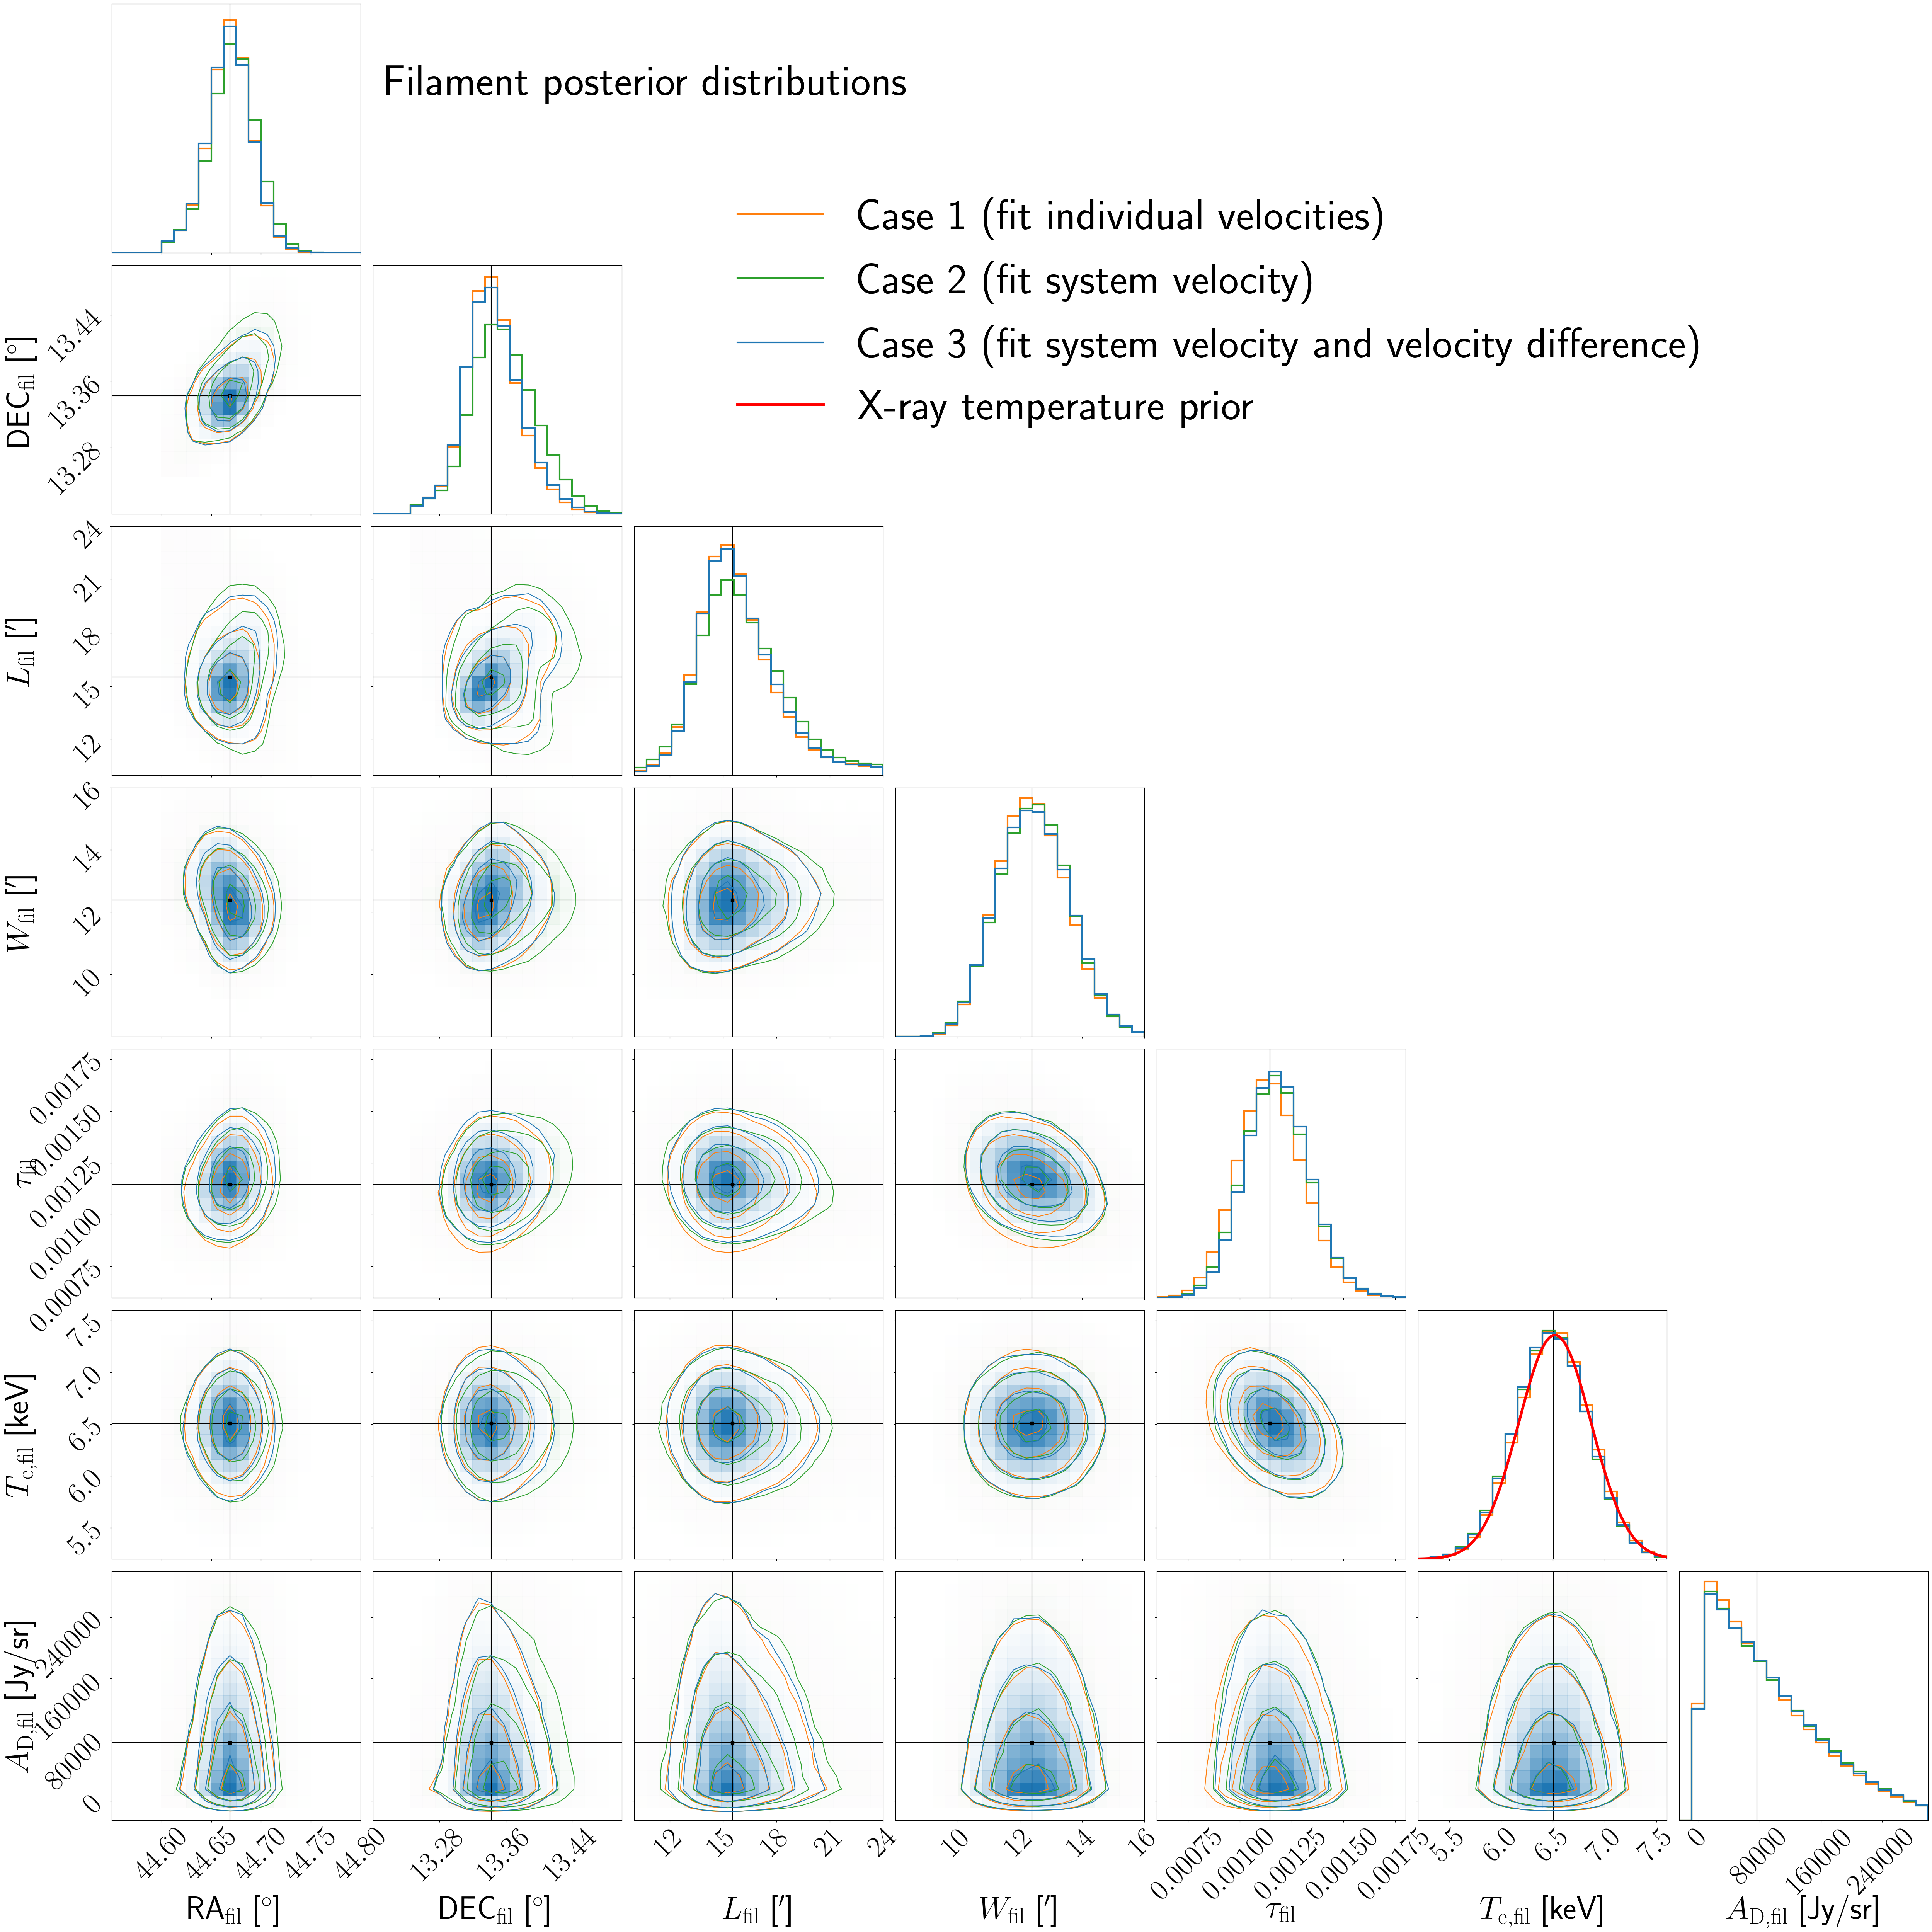

In [25]:
target = "bridge"

labels_a401 = [r'RA$_{\rm A401}$ [$^{\circ}$]', 
            r'DEC$_{\rm A401}$ [$^{\circ}$]', 
            r'$\beta_{\rm A401}$', 
            r'$r_{\rm c, A401}$ [$^{\prime}$]', 
            r'$e_{\rm A401}$', 
            r'$\theta_{\rm A401}$ [$^{\circ}$]', 
            r'$\tau_{\rm A401}$', 
            r'$T_{\rm e, A401}$ [keV]', 
            r'$A_{\rm D, A401}$ [Jy/sr]',
            r"$v_{\rm r, A401}$ [km/s]"]

labels_a399 = [r'$RA_{\rm A399}$ [$^{\circ}$]', 
            r'$DEC_{\rm A399}$ [$^{\circ}$]', 
            r'$\beta_{\rm A399}$', 
            r'$r_{\rm c, A399}$ [$^{\prime}$]', 
            r'$e_{\rm A399}$', 
            r'$\theta_{\rm A399}$ [$^{\circ}$]', 
            r'$\tau_{\rm A399}$', 
            r'$T_{\rm e, A399}$ [keV]', 
            r'$A_{\rm D, A399}$ [Jy/sr]',
            r"$v_{\rm r, A399}$ [km/s]"]

labels_fil =  [r"RA$_{\rm fil}$ [$^{\circ}$]",
            r"DEC$_{\rm fil}$ [$^{\circ}$]",
            r"$L_{\rm fil}$ [$^{\prime}$]",
            r"$W_{\rm fil}$ [$^{\prime}$]",
            r'$\tau_{\rm fil}$',
            r'$T_{\rm e, fil}$ [keV]',
            r'$A_{\rm D, fil}$ [Jy/sr]',
            r"$v_{\rm r, fil}$ [km/s]"]

p_range_a401 = [(44.736, 44.746),
               (13.57, 13.59),
               (0.95, 1.3),
               (3., 5.6),
               (0.6, 1),
               (80, 140),
               (.0055, .009),
               (7.5, 9.5),
               (-1e5, .9e6),
               (-3000, 3000)]

p_range_a399 = [(44.45, 44.476),
               (13.025, 13.052),
               (.75, 1.4),
               (2.4, 5.7),
               (.6, 1.3),
               (40, 180),
               (.005, .008),
               (6.4, 8),
               (-50e3, 600e3)]

p_range_fil = [(44.55, 44.8),
               (13.2, 13.5),
               (10, 24),
               (8, 16),
               (.0006, 0.0018),
               (5.2, 7.6),
               (-25e3, 300e3)]

# Use case54 configuration as reference (case 1)
case = "case54"

config = f"/home/gill/research/ACT/multi-freq-bridge/configs/{case}_ajay.yaml"
chain = f"/home/gill/research/ACT/bridge/results/ajay/final_runs/{case}/chain.h5"

# change plt parameters to tex font
plt.rcParams['text.usetex'] = 1

# Generate combined corner plot for cases 1, 2, and 3
model_tot= plotter_sim_fil(filename=chain, 
                            target=f"{target}",
                            plot_maps=0,           # Disable map plotting for corner plot focus
                            burnin=50000,
                            thin=1,
                            fit_dust=1,
                            plot_contours=1,       # Enable corner plot generation
                            p_range=p_range_fil,
                            plot_samples=0,
                            cf_path=config,
                            plot_converge=0)